In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/emineyetm/fake-news-detection-datasets/News _dataset/True.csv
/kaggle/input/datasets/emineyetm/fake-news-detection-datasets/News _dataset/Fake.csv


In [2]:
df_true = pd.read_csv('/kaggle/input/datasets/emineyetm/fake-news-detection-datasets/News _dataset/True.csv')
df_false = pd.read_csv('/kaggle/input/datasets/emineyetm/fake-news-detection-datasets/News _dataset/Fake.csv')

In [3]:
df_true["label"] = 1
df_false["label"] = 0

In [4]:
df_true.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


In [5]:
df_false.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [6]:
df = pd.concat([df_false, df_true], ignore_index=True)

In [7]:
# Randomly shuffle rows
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [8]:
X = df.drop('label',axis=1)
# axis = 1 means search along the columns and axis = 0 means search along the rows

Y = df['label']

In [9]:
X.head()

,title,text,subject,date
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017"
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017"
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017"
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017"
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016"


In [10]:
Y.head()

0    0
1    1
2    1
3    0
4    1
Name: label, dtype: int64

In [11]:
import tensorflow as tf

2026-05-19 23:05:54.013020: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779231954.393023      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779231954.496944      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779231955.420029      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779231955.420081      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779231955.420084      23 computation_placer.cc:177] computation placer alr

In [12]:
tf.__version__

'2.19.0'

In [13]:
from tensorflow.keras.layers import Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.text import one_hot
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense

In [14]:
## Vocabulary size
voc_size = 5000

## One Hot Representation

In [15]:
messages = X.copy()

In [16]:
messages['title'][1]

'Trump drops Steve Bannon from National Security Council'

In [17]:
import nltk
import re
from nltk.corpus import stopwords

In [18]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [19]:
## Data Preprocessing

from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))
corpus =[]
for i in range (0, len(messages)):
    if(i%1000 == 0):
        print(i)
    review = re.sub('[^a-zA-Z]',' ',messages['title'][i])
    review = review.lower()
    review = review.split()
    review = [ps.stem(word) for word in review if not word in stop_words] 
    review = ' '.join(review)
    corpus.append(review)

0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
23000
24000
25000
26000
27000
28000
29000
30000
31000
32000
33000
34000
35000
36000
37000
38000
39000
40000
41000
42000
43000
44000


In [20]:
import re
from tqdm import tqdm

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

corpus = []

# variables for longest sentence
max_sentence = ""
max_length = 0

for i in tqdm(range(len(messages)), desc="Processing"):

    # remove special chars
    review = re.sub('[^a-zA-Z]', ' ', messages['title'][i])

    # lowercase
    review = review.lower()

    # tokenize
    review = review.split()

    # lemmatize + remove stopwords
    review = [
        lemmatizer.lemmatize(word)
        for word in review
        if word not in stop_words
    ]

    # join back into sentence
    review = ' '.join(review)

    # find longest sentence
    if len(review) > max_length:
        max_length = len(review)
        max_sentence = review

    corpus.append(review)

print("\nLongest sentence:")
print(max_sentence)

print("\nLength:", max_length)

Processing: 100%|██████████| 44898/44898 [00:05<00:00, 8527.31it/s] 


Longest sentence:
breaking update last holdout declare war united state government liberty death clive bundy arrested way malheur wildlife refuge reverend franklin graham arrives scene oregon standoff live feed slow motion video lavoy finicum shooting death fbi

Length: 243


In [21]:
voc_size = 50000

In [22]:
# OHE or Hashing
one_hot_repr = [one_hot(words,voc_size) for words in corpus]
one_hot_repr[0:5]

[[726, 18893, 37690, 17743, 9248, 43228, 38847, 39296, 32935, 873],
 [46613, 14814, 12522, 24601, 32057, 18593, 7070],
 [39778, 40530, 29168, 22068, 18863, 19708, 32012, 30034, 25406],
 [46679, 46613, 1389, 6721, 22723, 43005, 19131, 13728, 39715],
 [1774, 46613, 46973, 18182, 12084, 46891, 8265]]

In [23]:
corpus[0:5]

['ben stein call th circuit court committed coup tat constitution',
 'trump drop steve bannon national security council',
 'puerto rico expects u lift jones act shipping restriction',
 'oops trump accidentally confirmed leaked israeli intelligence russia video',
 'donald trump head scotland reopen golf resort']

In [24]:
# Padding - making length of all sentences same
sent_length = 243
embedding_docs = pad_sequences(one_hot_repr, padding = 'pre',maxlen = sent_length)
print(embedding_docs)

[[    0     0     0 ... 39296 32935   873]
 [    0     0     0 ... 32057 18593  7070]
 [    0     0     0 ... 32012 30034 25406]
 ...
 [    0     0     0 ... 40635  6129 19917]
 [    0     0     0 ... 40048 41506 35135]
 [    0     0     0 ...  9404  7304 18335]]


In [25]:
embedding_docs[1]

array([    0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,

# Why not used TF-IDF here?

| TF-IDF | Word Embeddings |
|---|---|
| Based on word frequency | Based on semantic meaning |
| Sparse vectors | Dense vectors |
| Does not understand context | Captures context and similarity |
| Word order ignored | Sequence can be preserved |
| "good" and "excellent" are unrelated | Similar words have similar vectors |
| Used in ML models | Used in Deep Learning models |
| Best for Logistic Regression, Naive Bayes | Best for LSTM, GRU, Transformers |

In [26]:
# Creating model

embedding_vector_features = 40

model = Sequential()

# Embedding Layer
model.add(
    Embedding(
        voc_size,
        embedding_vector_features,
        input_length=sent_length
    )
)

# LSTM Layer
model.add(LSTM(100))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

# Compile model
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1779232010.131077      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779232010.136959      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [27]:
from tensorflow.keras.layers import Input

model = Sequential()
model.add(Input(shape=(sent_length,)))
model.add(Embedding(voc_size, embedding_vector_features))
model.add(LSTM(100))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 243, 40)        │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │        56,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,056,501 (7.84 MB)

 Trainable params: 2,056,501 (7.84 MB)

 Non-trainable params: 0 (0.00 B)

None


# Sequential Model

```python
model = Sequential()
```

Creates a neural network where layers are added one after another.

Flow:

```text
Input → Embedding → LSTM → Dense → Output
```

---

# Embedding Layer

```python
Embedding(voc_size, 40, input_length=sent_length)
```

- Converts each word index into a dense vector
- `40` = number of features per word

Example:

```text
12 → [0.2, -0.7, 1.1, ...]
```

So each word becomes a 40-dimensional vector.

---

# LSTM Layer

```python
LSTM(100)
```

- Learns sequence and context
- Understands word order
- `100` = number of LSTM neurons

Example:

```text
"not good" ≠ "very good"
```

---

# Dense Layer

```python
Dense(1, activation='sigmoid')
```

- Final prediction layer
- `1` neuron because binary classification
- Sigmoid outputs probability between 0 and 1

Example:

```text
0.91 → Real News
0.08 → Fake News
```

---

# Binary Cross Entropy Loss

```python
loss='binary_crossentropy'
```

Formula:

```text
L = -( y log(p) + (1-y) log(1-p) )
```

Where:
- `y` = actual label
- `p` = predicted probability

Used to measure prediction error.

---

# Adam Optimizer

```python
optimizer='adam'
```

- Updates neural network weights
- Adaptive learning rate optimizer
- Most commonly used optimizer

In [28]:
import numpy as np
X_final=np.array(embedding_docs)
y_final=np.array(Y)

In [29]:
X_final.shape,y_final.shape

((44898, 243), (44898,))

In [30]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.33, random_state=42)

# *Model Training*

In [31]:
### Finally Training
model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=20,batch_size=64)

Epoch 1/20


I0000 00:00:1779232014.987921      73 cuda_dnn.cc:529] Loaded cuDNN version 91002


471/471 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.8331 - loss: 0.3464 - val_accuracy: 0.9530 - val_loss: 0.1255
Epoch 2/20
471/471 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9679 - loss: 0.0866 - val_accuracy: 0.9567 - val_loss: 0.1120
Epoch 3/20
471/471 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9855 - loss: 0.0438 - val_accuracy: 0.9554 - val_loss: 0.1295
Epoch 4/20
471/471 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9932 - loss: 0.0228 - val_accuracy: 0.9515 - val_loss: 0.1653
Epoch 5/20
471/471 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9958 - loss: 0.0134 - val_accuracy: 0.9489 - val_loss: 0.1909
Epoch 6/20
471/471 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9980 - loss: 0.0075 - val_accuracy: 0.9495 - val_loss: 0.2317
Epoch 7/20
471/471 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9987 - loss: 0.0054 - val_accuracy: 0.9492 - val_loss: 0.2541
Epoch 8/20
471/471 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9985 - loss: 0.0047 - val_accuracy: 0.94

In [32]:
y_pred_probs = model.predict(X_test)         # keep these for ROC/AUC
y_pred = np.where(y_pred_probs > 0.6, 1, 0)  # use these for confusion matrix, accuracy, etc.

from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score
print(roc_auc_score(y_test, y_pred_probs))    # raw probabilities
print(confusion_matrix(y_test, y_pred))       # thresholded
print(accuracy_score(y_test, y_pred))         # thresholded

464/464 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
0.9866249354395502
[[7380  374]
 [ 423 6640]]
0.9462104339609908


In [33]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95      7754
           1       0.95      0.94      0.94      7063

    accuracy                           0.95     14817
   macro avg       0.95      0.95      0.95     14817
weighted avg       0.95      0.95      0.95     14817



In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc, 
    precision_recall_curve, classification_report
)

# Assuming you have:
# y_test       -> true labels
# y_pred_probs -> raw probabilities from model.predict(X_test)
# y_pred       -> thresholded predictions (0/1)

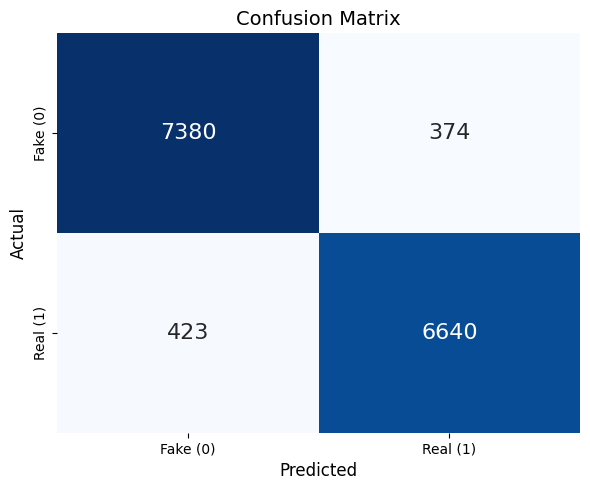

In [35]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Fake (0)', 'Real (1)'],
            yticklabels=['Fake (0)', 'Real (1)'],
            cbar=False, annot_kws={'size': 16})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.show()

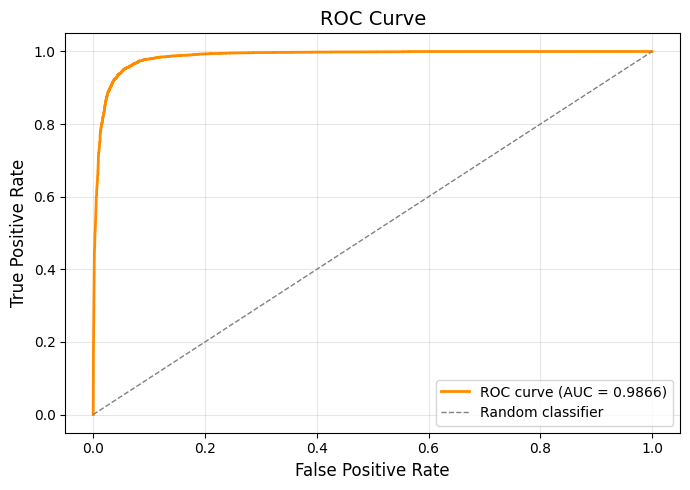

In [36]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', 
         label='Random classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve', fontsize=14)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

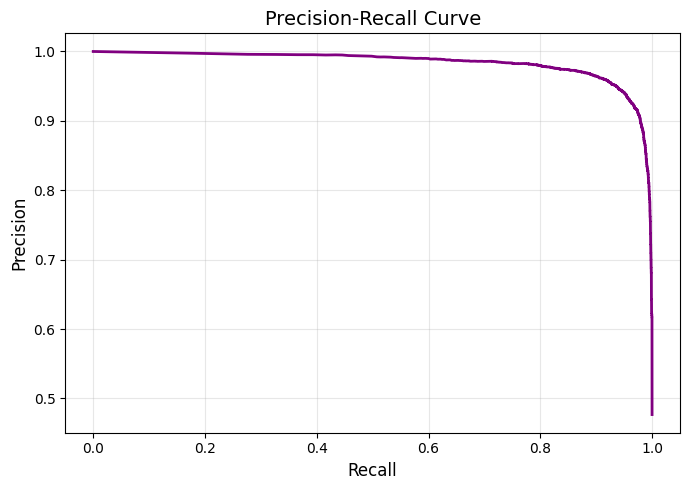

In [37]:
precision, recall, _ = precision_recall_curve(y_test, y_pred_probs)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, color='purple', lw=2)
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve', fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

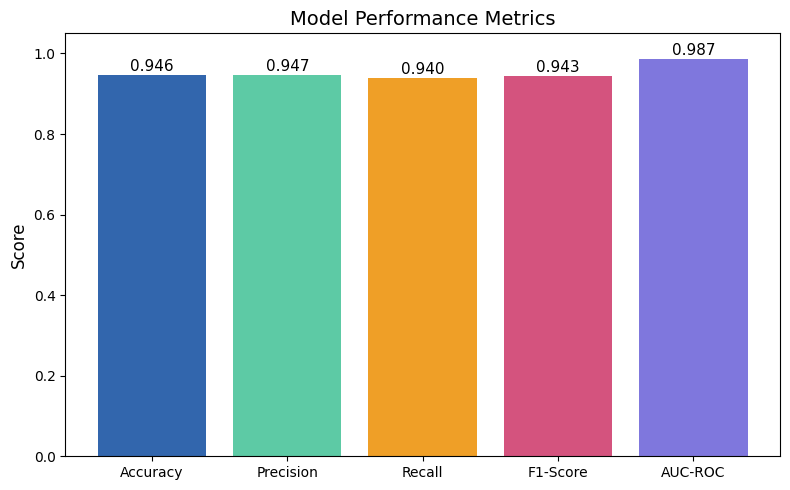

In [38]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

metrics = {
    'Accuracy':  accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall':    recall_score(y_test, y_pred),
    'F1-Score':  f1_score(y_test, y_pred),
    'AUC-ROC':   roc_auc
}

plt.figure(figsize=(8, 5))
bars = plt.bar(metrics.keys(), metrics.values(), 
               color=['#3266ad', '#5DCAA5', '#EF9F27', '#D4537E', '#7F77DD'])
plt.ylim(0, 1.05)
plt.ylabel('Score', fontsize=12)
plt.title('Model Performance Metrics', fontsize=14)
for bar, val in zip(bars, metrics.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{val:.3f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

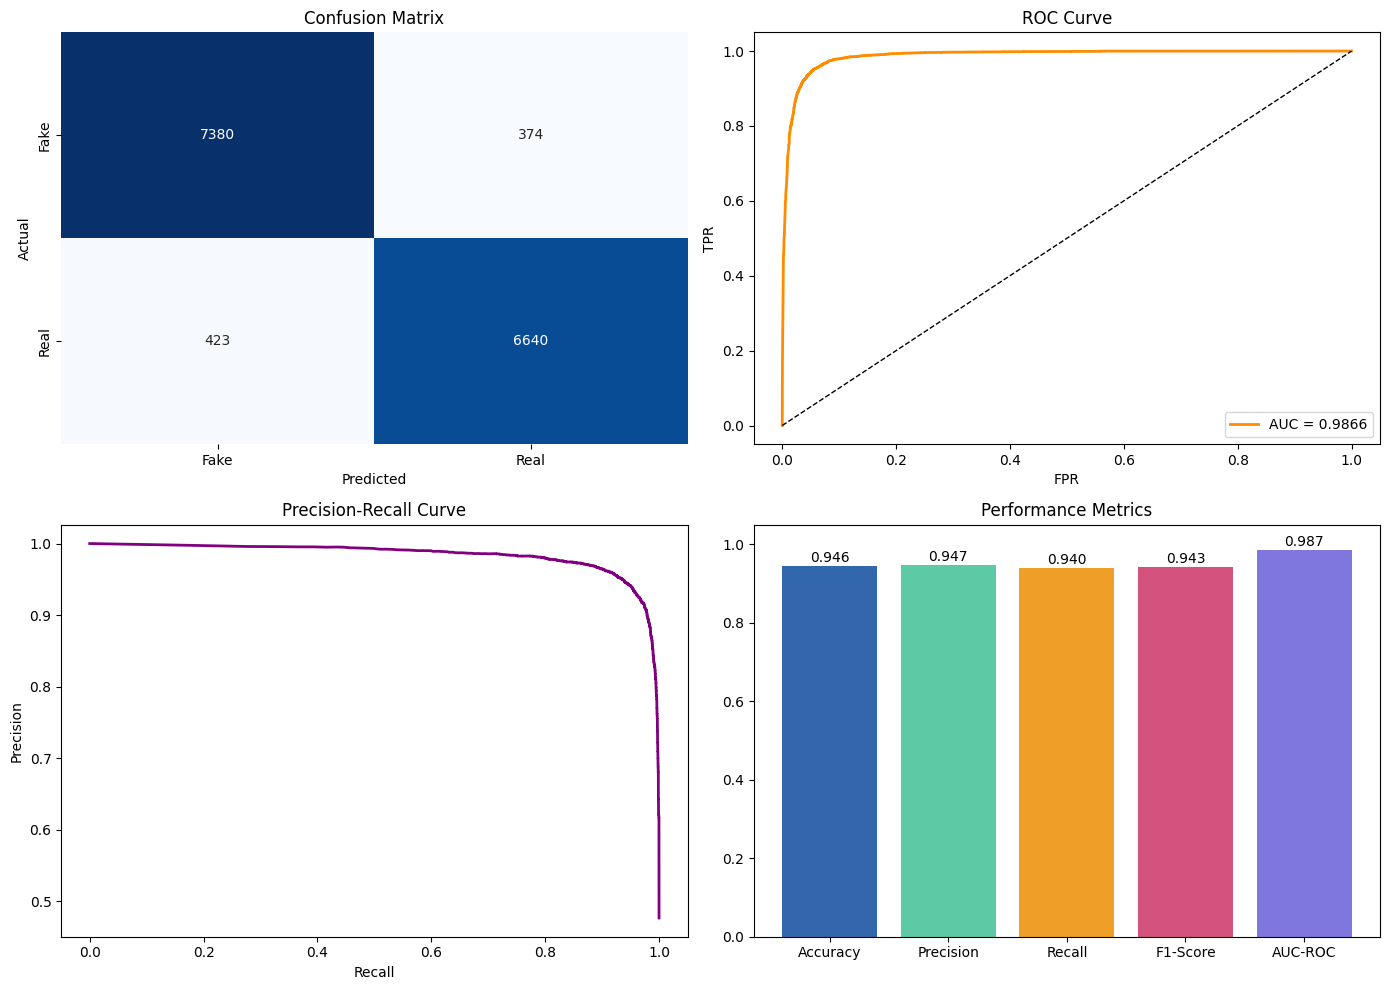

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0],
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'], cbar=False)
axes[0,0].set_title('Confusion Matrix')
axes[0,0].set_xlabel('Predicted'); axes[0,0].set_ylabel('Actual')

# ROC
axes[0,1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[0,1].plot([0,1], [0,1], 'k--', lw=1)
axes[0,1].set_title('ROC Curve'); axes[0,1].legend()
axes[0,1].set_xlabel('FPR'); axes[0,1].set_ylabel('TPR')

# PR Curve
axes[1,0].plot(recall, precision, color='purple', lw=2)
axes[1,0].set_title('Precision-Recall Curve')
axes[1,0].set_xlabel('Recall'); axes[1,0].set_ylabel('Precision')

# Metrics bar
axes[1,1].bar(metrics.keys(), metrics.values(), 
              color=['#3266ad', '#5DCAA5', '#EF9F27', '#D4537E', '#7F77DD'])
axes[1,1].set_ylim(0, 1.05); axes[1,1].set_title('Performance Metrics')
for i, v in enumerate(metrics.values()):
    axes[1,1].text(i, v + 0.01, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()

# Testing on real unseen data

In [40]:
import re
import nltk
import numpy as np
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.preprocessing.text import one_hot
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, confusion_matrix, classification_report
)

# Match your training setup
voc_size = 50000
sent_length = 243

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    review = re.sub('[^a-zA-Z]', ' ', text)
    review = review.lower().split()
    review = [lemmatizer.lemmatize(word) for word in review if word not in stop_words]
    return ' '.join(review)

# ============================================================
# TEST SET with ground-truth labels (1 = Real, 0 = Fake)
# ============================================================

test_data = [
    # Real news (label = 1)
    ("Federal Reserve announces interest rate cut amid economic uncertainty", 1),
    ("NASA Perseverance rover collects new rock samples from Mars surface", 1),
    ("European Union reaches agreement on artificial intelligence regulation", 1),
    ("Supreme Court rules on landmark constitutional case after months of deliberation", 1),
    ("Scientists discover new species of deep-sea fish near Pacific trench", 1),
    ("World Health Organization issues updated guidelines for pandemic preparedness", 1),
    ("Stock markets close higher following positive employment data release", 1),
    ("Researchers publish findings on climate change impact in peer-reviewed journal", 1),
    
    # Fake / sensational (label = 0)
    ("SHOCKING: Scientists confirm moon is made of cheese, government hides truth", 0),
    ("Aliens spotted at secret White House meeting, leaked footage goes viral", 0),
    ("Drinking bleach cures all diseases, doctors hate this simple trick", 0),
    ("BREAKING: President secretly replaced by clone, insider whistleblower reveals all", 0),
    ("Ancient pyramid found on Mars proves humans came from outer space", 0),
    ("Miracle pill makes you lose 50 pounds in one week without exercise", 0),
    ("Celebrity faked own death to escape government surveillance program", 0),
    ("5G towers proven to control minds, secret documents finally exposed", 0),
]

headlines = [h for h, _ in test_data]
y_true = np.array([label for _, label in test_data])

# Preprocess + predict
cleaned = [preprocess(h) for h in headlines]
onehot = [one_hot(words, voc_size) for words in cleaned]
padded = pad_sequences(onehot, padding='pre', maxlen=sent_length)
probs = model.predict(np.array(padded), verbose=0).flatten()
y_pred = (probs > 0.6).astype(int)

# ============================================================
# Per-headline results
# ============================================================
results = pd.DataFrame({
    'Headline': [h[:55] + '...' if len(h) > 55 else h for h in headlines],
    'Actual': ['Real' if l == 1 else 'Fake' for l in y_true],
    'Predicted': ['Real' if p == 1 else 'Fake' for p in y_pred],
    'Confidence': [f"{p:.3f}" for p in probs],
    'Correct': ['✓' if t == p else '✗' for t, p in zip(y_true, y_pred)]
})
print(results.to_string(index=False))

# ============================================================
# Metrics
# ============================================================
print("\n" + "="*60)
print("METRICS ON UNSEEN DATA")
print("="*60)
print(f"Accuracy:  {accuracy_score(y_true, y_pred):.3f}")
print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.3f}")
print(f"Recall:    {recall_score(y_true, y_pred, zero_division=0):.3f}")
print(f"F1-Score:  {f1_score(y_true, y_pred, zero_division=0):.3f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Fake', 'Real'], zero_division=0))

                                                  Headline Actual Predicted Confidence Correct
Federal Reserve announces interest rate cut amid econom...   Real      Real      1.000       ✓
NASA Perseverance rover collects new rock samples from ...   Real      Fake      0.018       ✗
European Union reaches agreement on artificial intellig...   Real      Real      1.000       ✓
Supreme Court rules on landmark constitutional case aft...   Real      Real      1.000       ✓
Scientists discover new species of deep-sea fish near P...   Real      Real      0.932       ✓
World Health Organization issues updated guidelines for...   Real      Real      1.000       ✓
Stock markets close higher following positive employmen...   Real      Fake      0.000       ✗
Researchers publish findings on climate change impact i...   Real      Real      0.865       ✓
SHOCKING: Scientists confirm moon is made of cheese, go...   Fake      Fake      0.000       ✓
Aliens spotted at secret White House meeting, leak